# 1. Beamforming with loops

We locate a source from the recordings of an array of sensors, in three steps:

1. **Geometry**: sensors, source, and a grid of candidate source positions
2. **Recordings**: what the sensors record
3. **Beamforming**: compare the recordings with what we would expect for a source at each grid point

Notebooks 1–3 do exactly the same; only step 3 differs. Here, step 3 is written as plain loops that follow the formula: slow, but the clearest way to see what a beamformer computes.

## 1. Geometry

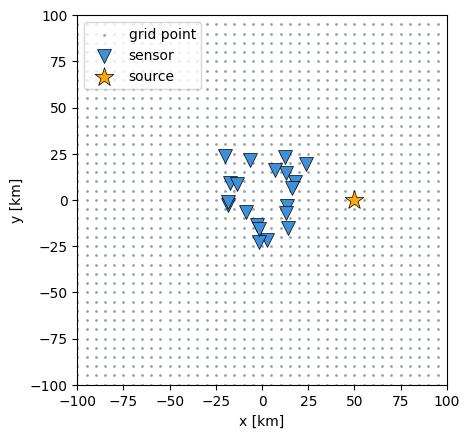

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

# 20 sensors, placed at random in a 50 km x 50 km square
rng = np.random.default_rng(42)
n_sensors = 20
stations = rng.uniform(-25, 25, size=(n_sensors, 2))
source = np.array([50, 0])

# candidate source positions: a grid with 5 km spacing
grid_coords = np.arange(-100, 100, 5)
xx, yy = np.meshgrid(grid_coords, grid_coords, indexing="ij")
gridpoints = np.stack([xx.ravel(), yy.ravel()], axis=1)

fig, ax = plt.subplots()
ax.scatter(*gridpoints.T, s=1, c="#94a4a2", label="grid point")
ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]")
ax.legend(loc="upper left")

## 2. Recordings

The source emits a short pulse. It reaches sensor $j$ after the traveltime $t_j = |\mathbf{r}_j - \mathbf{r}_\text{source}| / c$. In the frequency domain, a delay by $t_j$ is a multiplication with $e^{-i\omega t_j}$. With field data, use the spectra of your recordings instead.

[(0.0, 60.0),
 Text(0.5, 0, 'time [s]'),
 Text(0, 0.5, 'amplitude'),
 Text(0.5, 1.0, 'recordings')]

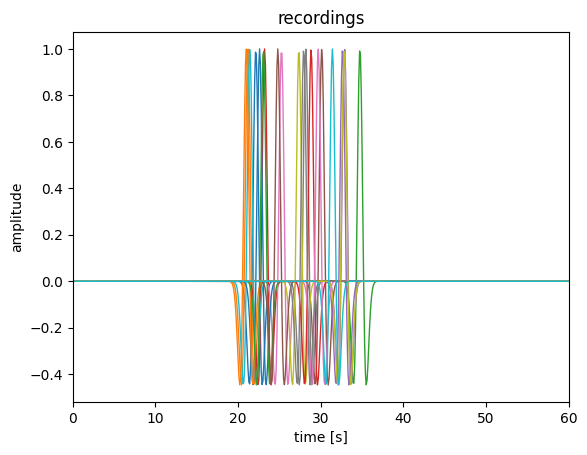

In [2]:
sampling_rate = 10  # Hz
times = np.arange(0, 100, 1 / sampling_rate)  # 100 s
freqs = np.fft.fftfreq(len(times), 1 / sampling_rate)
omega = 2 * np.pi * freqs

medium_velocity = 3  # km/s
traveltimes = np.linalg.norm(stations - source, axis=1) / medium_velocity


def ricker(t, peak_frequency, delay):
    arg = (np.pi * peak_frequency * (t - delay)) ** 2
    return (1 - 2 * arg) * np.exp(-arg)


# every sensor records the same pulse, delayed by its traveltime
pulse_spectrum = np.fft.fft(ricker(times, peak_frequency=0.5, delay=10))
waveform_spectra = pulse_spectrum * np.exp(-1j * omega * traveltimes[:, None])
waveforms = np.fft.ifft(waveform_spectra).real

# we beamform between 0.1 and 1 Hz
band = (freqs > 0.1) & (freqs < 1.0)
omega_band = omega[band]
spectra = waveform_spectra[:, band]

fig, ax = plt.subplots()
ax.plot(times, waveforms.T, lw=1)
ax.set(xlim=(0, 60), xlabel="time [s]", ylabel="amplitude", title="recordings")

## 3. Beamforming

**Cross-spectral density matrix.** For every pair of sensors $j, k$ and every frequency $\omega$, we multiply the spectrum of one recording with the complex conjugate of the other:

$K_{jk}(\omega) = d_j(\omega)\, d_k^*(\omega).$

This is the cross-correlation of the two recordings, in the frequency domain. Its phase is the time lag between them.

**Steering vector.** For a candidate source at grid point $\mathbf{x}$, we expect the wave to reach sensor $j$ after the traveltime $t_j(\mathbf{x})$. The steering vector holds these delays as phases:

$s_j(\mathbf{x}, \omega) = e^{-i\omega t_j(\mathbf{x})}.$

**Beampower.** We compare both:

$B(\mathbf{x}) = \sum_\omega \mathbf{s}^H K\, \mathbf{s} = \sum_\omega \sum_j \sum_k s_j^*\, K_{jk}\, s_k.$

Each term, $K_{jk}\, e^{i\omega (t_j - t_k)}$, shifts the correlation of sensors $j$ and $k$ by the time lag that we expect between them. Summed over all pairs, this is a delay-and-sum of the correlations. It is largest at the grid point whose expected time lags match the recorded ones.

We leave out the pairs $j = k$, the auto-correlations: they hold no time lag, only the energy of each recording. This is the **cross-correlation beamformer**. (Keeping them gives the Bartlett beamformer, see notebook 4.)

In [3]:
title = "loops"
start = time.perf_counter()

# cross-spectral density matrix of the recordings
K = np.zeros((n_sensors, n_sensors, len(omega_band)), dtype=complex)
for j in range(n_sensors):
    for k in range(n_sensors):
        K[j, k] = spectra[j] * np.conj(spectra[k])

beampowers = np.zeros(len(gridpoints))
for x, gridpoint in enumerate(gridpoints):
    # steering vector for this grid point: one row of phases per sensor
    s = []
    for station in stations:
        traveltime = np.linalg.norm(gridpoint - station) / medium_velocity
        s.append(np.exp(-1j * omega_band * traveltime))
    # s^H K s, without the auto-correlations (numpy sums over the frequencies)
    for j in range(n_sensors):
        for k in range(n_sensors):
            if j != k:
                beampowers[x] += np.sum(np.conj(s[j]) * K[j, k] * s[k]).real

runtime = time.perf_counter() - start
print(f"beamforming took {runtime:.1f} s")

beamforming took 3.3 s


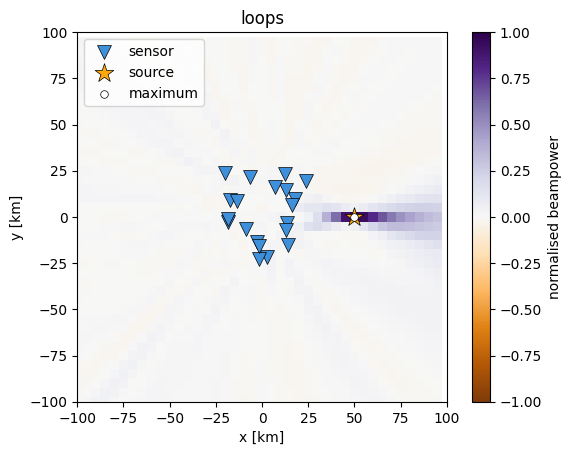

In [4]:
def plot_beampowers(beampowers, title):
    bp = beampowers.reshape(len(grid_coords), len(grid_coords)).T
    bp = bp / np.abs(bp).max()
    fig, ax = plt.subplots()
    pcm = ax.pcolormesh(grid_coords, grid_coords, bp, cmap="PuOr", vmin=-1, vmax=1, shading="nearest")
    ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
    ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
    ax.scatter(*gridpoints[np.argmax(beampowers)], marker="o", s=30, c="w", ec="k", lw=0.5, label="maximum")
    fig.colorbar(pcm, label="normalised beampower")
    ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]", title=title)
    ax.legend(loc="upper left")


plot_beampowers(beampowers, title)

The beampower is largest at the source. Negative values mean that the recorded time lags are opposite to the expected ones.

The loops visit every grid point and every pair of sensors, so the runtime grows with $n_\text{gridpoints} \times n_\text{sensors}^2$. Notebook 2 computes the same with array operations in `numpy`, much faster.